In [28]:
import numpy as np
from matplotlib.colors import hsv_to_rgb
import matplotlib.pyplot as plt


In [29]:
base = "100_200_100_200"
extension = "1d"
orig_height = int(base.split("_")[-2])
orig_width = int(base.split("_")[-1])
print(orig_height, orig_width)

100 200


In [30]:
magdir_height = orig_height - 2
magdir_width = orig_width - 2
odarr= np.fromfile(f"./data/{base}_{extension}.magdir.bin", dtype=np.float32)
refarr= np.fromfile(f"./data/{base}.magdir.bin", dtype=np.float32)
print(magdir_height * magdir_width, magdir_height * magdir_width*2, refarr.shape, odarr.shape)
print(np.any(np.isnan(odarr)))


19404 38808 (38808,) (38808,)
False


In [31]:
def visualize_vector_field(mag, direction, h, w):
    """
    mag: 2D array of floats (0-255)
    direction: 2D array of floats (-pi to pi)
    """
    MAX_SOBEL_VALUE = np.sqrt(2) * 4 * 255 # when gx,gy = 255; technically over esimate
    mag = mag/MAX_SOBEL_VALUE*255
    
    mag = mag.reshape(h,w)

    direction = direction.reshape(h,w)
    
    # 1. Create an empty HSV image
    # Shape: (height, width, 3)
    hsv = np.zeros((h, w, 3), dtype=np.float32)
    
    # 2. Map Direction to Hue [0, 1]
    # We shift -pi...pi to 0...2pi, then normalize to 0...1
    hsv[..., 0] = (direction + np.pi) / (2 * np.pi)
    
    # 3. Set Saturation to maximum
    hsv[..., 1] = 1.0
    
    # 4. Map Magnitude to Value [0, 1]
    # Ensure it's clipped and normalized
    hsv[..., 2] = np.clip(mag, 0, 255) / 255.0
    
    # 5. Convert HSV to RGB for display
    rgb = hsv_to_rgb(hsv)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.title("Magnitude (Brightness) & Direction (Color)")
    plt.axis('off')
    plt.show()


# should look like: 

0.0 1120.723
-3.140107 3.1415927


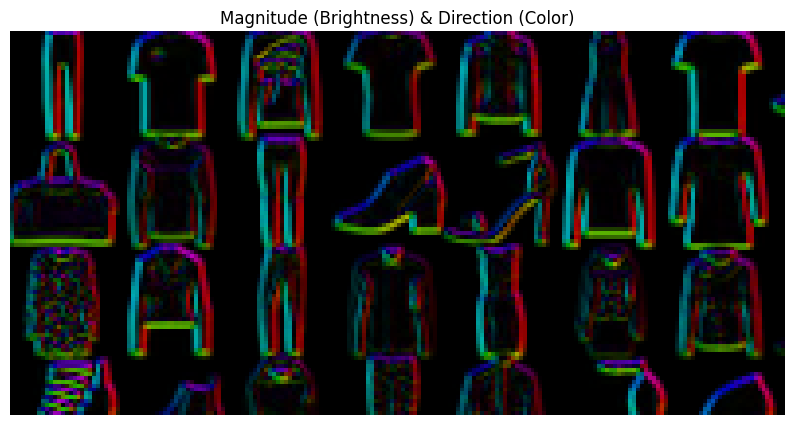

In [32]:
ref_mags = refarr[:(magdir_height*magdir_width)]
ref_dirs = refarr[(magdir_height*magdir_width):]
print(ref_mags.min(), ref_mags.max())
print(ref_dirs.min(), ref_dirs.max())
visualize_vector_field(ref_mags, ref_dirs, magdir_height, magdir_width)

# actually looks like

0.0 1120.723
-3.1401067 3.1415927
False


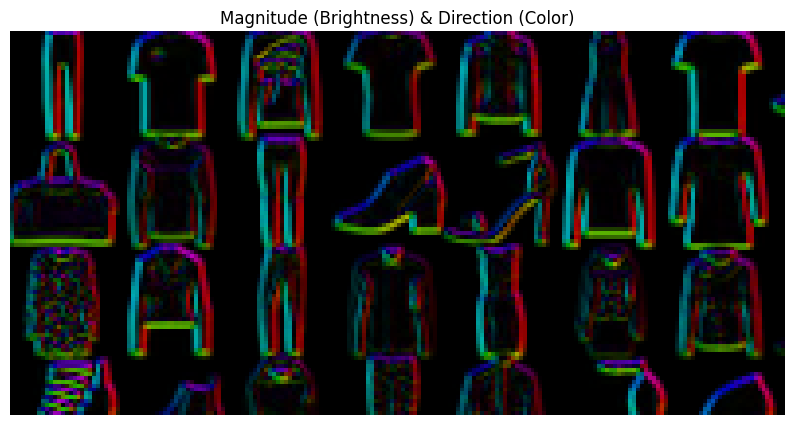

In [33]:
mags = odarr[:(magdir_height*magdir_width)]
print(mags.min(), mags.max())
dirs = odarr[(magdir_height*magdir_width):(magdir_height*magdir_width*2)]
print(dirs.min(), dirs.max())
print(np.any(np.isnan(odarr)))
# print(odarr[:(magdir_height*magdir_width*2)])
visualize_vector_field(mags, dirs, magdir_height, magdir_width)

# any difference? 

In [34]:
print(np.allclose(mags, ref_mags), np.absolute(mags- ref_mags).max())
print(np.allclose(dirs, ref_dirs), np.absolute(dirs - ref_dirs).max())


True 0.0
True 4.7683716e-07


In [35]:
def gen(): 
    c = 0
    with np.printoptions(threshold=np.inf, precision=1):
        while True:
            r1 = odarr[c*magdir_height:(c+1)*magdir_height]
            r2 = refarr[c*magdir_height:(c+1)*magdir_height]
            print(c, end=", ")
            c+=1
            if np.all(np.isclose(r1, r2)): 
                continue
            else: 
                print(c)
                print(r1)
                print(r2)
                print(r1 - r2)
                yield
a = gen()

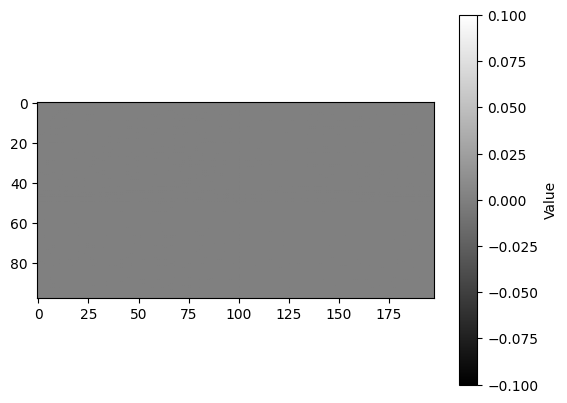

In [36]:
plt.imshow((ref_mags!=mags).reshape(magdir_height,magdir_width), cmap='gray')
plt.colorbar( label='Value')
plt.show()

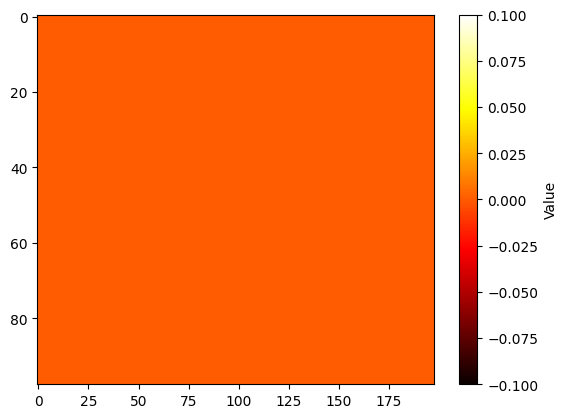

In [37]:
plt.imshow((mags-ref_mags).reshape(magdir_height,magdir_width), cmap='hot', aspect='auto')
plt.colorbar(label='Value')
plt.show()

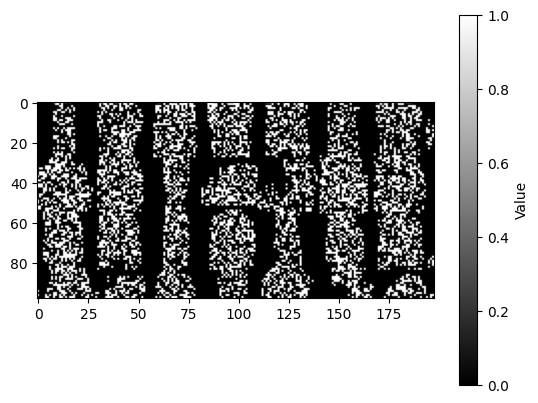

In [38]:
plt.imshow((dirs!=ref_dirs).reshape(magdir_height,magdir_width), cmap='gray')
plt.colorbar( label='Value')
plt.show()

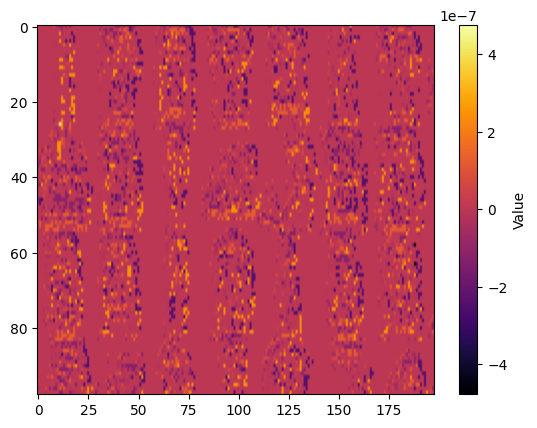

In [39]:
plt.imshow((dirs-ref_dirs).reshape(magdir_height,magdir_width), cmap='inferno', aspect='auto')
plt.colorbar( label='Value')
plt.show()